In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import math

print("Büyük Dil Modelleri ve Fine-tuning")
print("=" * 40)
print()
print("Bugün işleyeceklerimiz:")
print("1. LLM mimarileri — GPT vs BERT vs T5")
print("2. Fine-tuning stratejileri")
print("3. LoRA matematiği ve implementation")
print("4. Gerçek dünyada LLM fine-tuning")
print()
print("Soru: 70B parametreli modeli")
print("nasıl kendi verimizle eğitebiliriz?")
print("Cevap: LoRA!")

torch.manual_seed(42)

Büyük Dil Modelleri ve Fine-tuning

Bugün işleyeceklerimiz:
1. LLM mimarileri — GPT vs BERT vs T5
2. Fine-tuning stratejileri
3. LoRA matematiği ve implementation
4. Gerçek dünyada LLM fine-tuning

Soru: 70B parametreli modeli
nasıl kendi verimizle eğitebiliriz?
Cevap: LoRA!


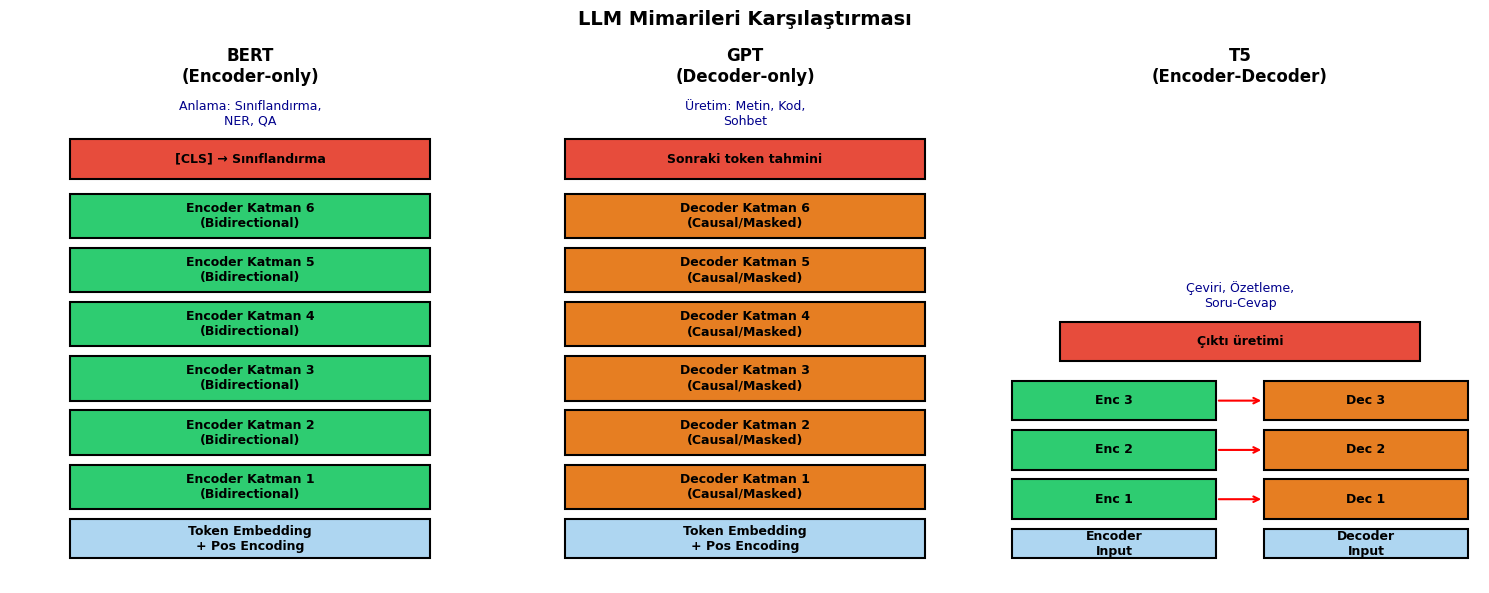

Model      Mimari               Eğitim               Kullanım       
-----------------------------------------------------------------
BERT       Encoder-only         Masked LM            Anlama         
GPT-4      Decoder-only         Causal LM            Üretim         
T5         Enc-Dec              Span masking         Çeviri/Özet    
LLaMA      Decoder-only         Causal LM            Genel amaç     
Mistral    Decoder-only         Causal LM            Verimli üretim 


In [3]:
# LLM MİMARİLERİ KARŞILAŞTIRMASI
#
# 3 ana yaklaşım:
# 1. Encoder-only (BERT)    → Anlama görevleri
# 2. Decoder-only (GPT)     → Üretim görevleri
# 3. Encoder-Decoder (T5)   → Çeviri, özetleme

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

def draw_block(ax, x, y, w, h, text, color):
    ax.add_patch(plt.Rectangle((x, y), w, h,
                facecolor=color, edgecolor='black', linewidth=1.5))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
           fontsize=9, fontweight='bold')

# BERT — Encoder only
ax = axes[0]
ax.set_xlim(0, 4)
ax.set_ylim(0, 10)
ax.axis('off')

# Input
draw_block(ax, 0.5, 0.5, 3, 0.8, "Token Embedding\n+ Pos Encoding", '#AED6F1')
# Encoder katmanları
for i in range(6):
    draw_block(ax, 0.5, 1.5 + i*1.1, 3, 0.9,
               f"Encoder Katman {i+1}\n(Bidirectional)", '#2ECC71')
# Output
draw_block(ax, 0.5, 8.2, 3, 0.8, "[CLS] → Sınıflandırma", '#E74C3C')

ax.set_title("BERT\n(Encoder-only)", fontsize=12, fontweight='bold')
ax.text(2, 9.3, "Anlama: Sınıflandırma,\nNER, QA", ha='center', fontsize=9,
       color='darkblue')

# GPT — Decoder only
ax = axes[1]
ax.set_xlim(0, 4)
ax.set_ylim(0, 10)
ax.axis('off')

draw_block(ax, 0.5, 0.5, 3, 0.8, "Token Embedding\n+ Pos Encoding", '#AED6F1')
for i in range(6):
    draw_block(ax, 0.5, 1.5 + i*1.1, 3, 0.9,
               f"Decoder Katman {i+1}\n(Causal/Masked)", '#E67E22')
draw_block(ax, 0.5, 8.2, 3, 0.8, "Sonraki token tahmini", '#E74C3C')

ax.set_title("GPT\n(Decoder-only)", fontsize=12, fontweight='bold')
ax.text(2, 9.3, "Üretim: Metin, Kod,\nSohbet", ha='center', fontsize=9,
       color='darkblue')

# T5 — Encoder-Decoder
ax = axes[2]
ax.set_xlim(0, 4)
ax.set_ylim(0, 10)
ax.axis('off')

draw_block(ax, 0.1, 0.5, 1.7, 0.6, "Encoder\nInput", '#AED6F1')
draw_block(ax, 2.2, 0.5, 1.7, 0.6, "Decoder\nInput", '#AED6F1')

for i in range(3):
    draw_block(ax, 0.1, 1.3 + i*1.0, 1.7, 0.8,
               f"Enc {i+1}", '#2ECC71')
    draw_block(ax, 2.2, 1.3 + i*1.0, 1.7, 0.8,
               f"Dec {i+1}", '#E67E22')
    # Cross-attention oku
    ax.annotate('', xy=(2.2, 1.7 + i*1.0),
                xytext=(1.8, 1.7 + i*1.0),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

draw_block(ax, 0.5, 4.5, 3, 0.8, "Çıktı üretimi", '#E74C3C')

ax.set_title("T5\n(Encoder-Decoder)", fontsize=12, fontweight='bold')
ax.text(2, 5.6, "Çeviri, Özetleme,\nSoru-Cevap", ha='center', fontsize=9,
       color='darkblue')

plt.suptitle("LLM Mimarileri Karşılaştırması", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Karşılaştırma tablosu
print("=" * 65)
print(f"{'Model':10s} {'Mimari':20s} {'Eğitim':20s} {'Kullanım':15s}")
print("-" * 65)
modeller = [
    ("BERT", "Encoder-only", "Masked LM", "Anlama"),
    ("GPT-4", "Decoder-only", "Causal LM", "Üretim"),
    ("T5", "Enc-Dec", "Span masking", "Çeviri/Özet"),
    ("LLaMA", "Decoder-only", "Causal LM", "Genel amaç"),
    ("Mistral", "Decoder-only", "Causal LM", "Verimli üretim"),
]
for m in modeller:
    print(f"{m[0]:10s} {m[1]:20s} {m[2]:20s} {m[3]:15s}")

LoRA Parametre Analizi:
r= 1: LoRA= 1,024 | Original=262,144 | Oran=%0.4
r= 2: LoRA= 2,048 | Original=262,144 | Oran=%0.8
r= 4: LoRA= 4,096 | Original=262,144 | Oran=%1.6
r= 8: LoRA= 8,192 | Original=262,144 | Oran=%3.1
r=16: LoRA=16,384 | Original=262,144 | Oran=%6.2
r=32: LoRA=32,768 | Original=262,144 | Oran=%12.5


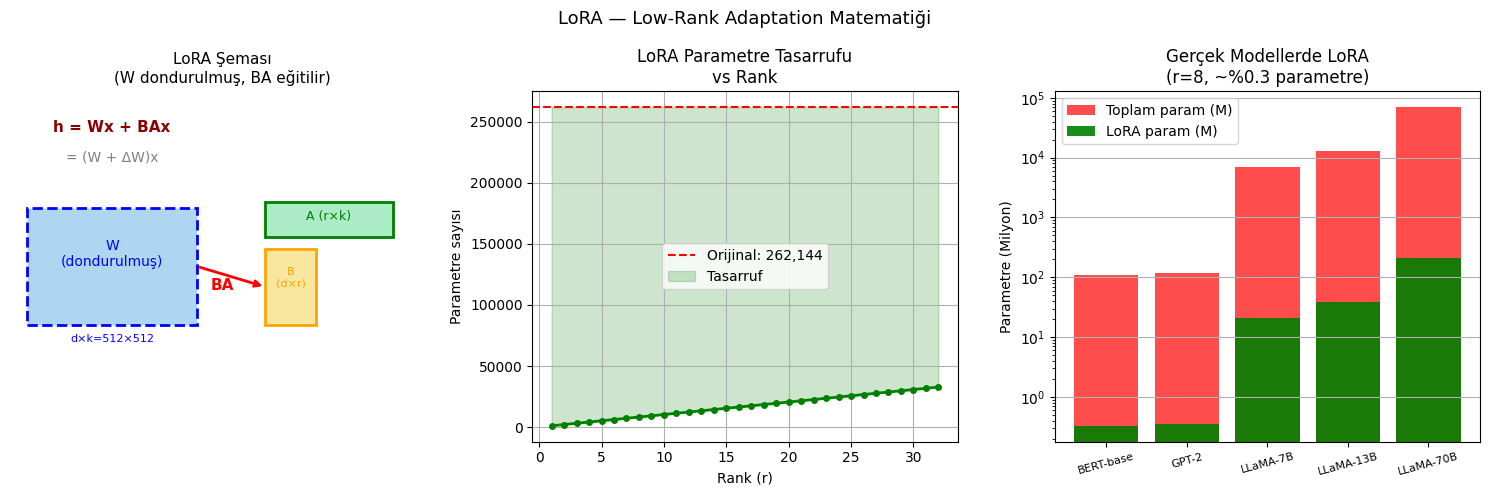

In [4]:
# LORA — LOW-RANK ADAPTATION
#
# Problem: 70B model fine-tune etmek = 70B * 4 byte = 280GB GPU RAM!
# Çözüm: Sadece küçük ek matrisler eğit
#
# Orijinal ağırlık: W ∈ R^(d×k)  — dondurulmuş!
# LoRA eklentisi:   ΔW = B * A
#   A ∈ R^(r×k)  — küçük matris
#   B ∈ R^(d×r)  — küçük matris
#   r << d, k    — rank, genelde 4-16
#
# İleri besleme: h = Wx + BAx
#              = (W + BA)x
#
# Parametre tasarrufu:
# Original: d*k
# LoRA:     r*(d+k)  → r=8, d=k=512: 8*1024=8192 vs 512*512=262144
# Oran: 8192/262144 = %3.1!

print("LoRA Parametre Analizi:")
print("=" * 50)

d, k = 512, 512
for r in [1, 2, 4, 8, 16, 32]:
    original = d * k
    lora = r * (d + k)
    oran = lora / original * 100
    print(f"r={r:2d}: LoRA={lora:6,} | Original={original:,} | Oran=%{oran:.1f}")

# Görselleştir
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# LoRA şeması
ax = axes[0]
ax.set_xlim(0, 5)
ax.set_ylim(0, 6)
ax.axis('off')

# W matrisi (büyük, dondurulmuş)
ax.add_patch(plt.Rectangle((0.2, 2), 2, 2,
            facecolor='#AED6F1', edgecolor='blue', linewidth=2,
            linestyle='--'))
ax.text(1.2, 3, 'W\n(dondurulmuş)', ha='center', fontsize=10,
       color='blue')
ax.text(1.2, 1.7, f'd×k={d}×{k}', ha='center', fontsize=8, color='blue')

# A matrisi (küçük)
ax.add_patch(plt.Rectangle((3, 3.5), 1.5, 0.6,
            facecolor='#ABEBC6', edgecolor='green', linewidth=2))
ax.text(3.75, 3.8, 'A (r×k)', ha='center', fontsize=9, color='green')

# B matrisi (küçük)
ax.add_patch(plt.Rectangle((3, 2), 0.6, 1.3,
            facecolor='#F9E79F', edgecolor='orange', linewidth=2))
ax.text(3.3, 2.65, 'B\n(d×r)', ha='center', fontsize=8, color='orange')

# Oklar
ax.annotate('', xy=(3, 2.65), xytext=(2.2, 3),
           arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(2.5, 2.6, 'BA', ha='center', fontsize=11,
       color='red', fontweight='bold')
ax.text(1.2, 5.3, 'h = Wx + BAx', ha='center', fontsize=11,
       fontweight='bold', color='darkred')
ax.text(1.2, 4.8, '= (W + ΔW)x', ha='center', fontsize=10, color='gray')
ax.set_title("LoRA Şeması\n(W dondurulmuş, BA eğitilir)", fontsize=11)

# Rank vs parametre
r_values = range(1, 33)
params_lora = [r*(d+k) for r in r_values]
params_orig = d * k

axes[1].plot(r_values, params_lora, 'g-o', linewidth=2, markersize=4)
axes[1].axhline(y=params_orig, color='red', linestyle='--',
               label=f'Orijinal: {params_orig:,}')
axes[1].fill_between(r_values, params_lora, params_orig,
                    alpha=0.2, color='green', label='Tasarruf')
axes[1].set_title("LoRA Parametre Tasarrufu\nvs Rank")
axes[1].set_xlabel("Rank (r)")
axes[1].set_ylabel("Parametre sayısı")
axes[1].legend()
axes[1].grid(True)

# Büyük modellerde tasarruf
modeller_lora = [
    ("BERT-base", 110e6, 0.003),
    ("GPT-2", 117e6, 0.003),
    ("LLaMA-7B", 7e9, 0.003),
    ("LLaMA-13B", 13e9, 0.003),
    ("LLaMA-70B", 70e9, 0.003),
]

isimler = [m[0] for m in modeller_lora]
toplam = [m[1]/1e6 for m in modeller_lora]
lora_params = [m[1]*m[2]/1e6 for m in modeller_lora]

x_pos = range(len(isimler))
axes[2].bar(x_pos, toplam, color='red', alpha=0.7, label='Toplam param (M)')
axes[2].bar(x_pos, lora_params, color='green', alpha=0.9, label='LoRA param (M)')
axes[2].set_title("Gerçek Modellerde LoRA\n(r=8, ~%0.3 parametre)")
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(isimler, rotation=15, fontsize=8)
axes[2].set_ylabel("Parametre (Milyon)")
axes[2].legend()
axes[2].set_yscale('log')
axes[2].grid(True, axis='y')

plt.suptitle("LoRA — Low-Rank Adaptation Matematiği", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
# LORA — TEMİZ IMPLEMENTATION

class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, rank=8, alpha=16):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.rank = rank
        self.scaling = alpha / rank

        # Orijinal ağırlık — dondurulmuş
        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.01,
            requires_grad=False
        )
        self.bias = nn.Parameter(
            torch.zeros(out_features),
            requires_grad=False
        )

        # LoRA matrisleri — eğitilecek
        self.lora_A = nn.Parameter(torch.randn(rank, in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))

    def forward(self, x):
        original = nn.functional.linear(x, self.weight, self.bias)
        lora = x @ self.lora_A.T @ self.lora_B.T * self.scaling
        return original + lora

# Basit sınıflandırma modeli — LoRA ile
class ModelWithLoRA(nn.Module):
    def __init__(self, d_model=256, n_classes=10, rank=8):
        super().__init__()
        self.fc1 = LoRALinear(d_model, 512, rank=rank)
        self.fc2 = LoRALinear(512, 512, rank=rank)
        self.fc3 = LoRALinear(512, n_classes, rank=rank)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        return self.fc3(x)

# Karşılaştırma — Normal vs LoRA
class NormalModel(nn.Module):
    def __init__(self, d_model=256, n_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(d_model, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, n_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        return self.fc3(x)

# Parametre analizi
for rank in [4, 8, 16]:
    model_lora = ModelWithLoRA(rank=rank)
    model_normal = NormalModel()

    total_lora = sum(p.numel() for p in model_lora.parameters())
    trainable_lora = sum(p.numel() for p in model_lora.parameters()
                        if p.requires_grad)
    total_normal = sum(p.numel() for p in model_normal.parameters())

    print(f"rank={rank:2d} | Normal: {total_normal:,} | "
          f"LoRA toplam: {total_lora:,} | "
          f"LoRA eğitilebilir: {trainable_lora:,} | "
          f"Oran: %{trainable_lora/total_normal*100:.1f}")

# Test
x = torch.randn(4, 256)
model_lora = ModelWithLoRA(rank=8)
model_normal = NormalModel()

out_lora = model_lora(x)
out_normal = model_normal(x)
print(f"\nLoRA çıktı shape:   {out_lora.shape}")
print(f"Normal çıktı shape: {out_normal.shape}")
print("\n✅ LoRA implement edildi!")

rank= 4 | Normal: 399,370 | LoRA toplam: 408,626 | LoRA eğitilebilir: 9,256 | Oran: %2.3
rank= 8 | Normal: 399,370 | LoRA toplam: 417,882 | LoRA eğitilebilir: 18,512 | Oran: %4.6
rank=16 | Normal: 399,370 | LoRA toplam: 436,394 | LoRA eğitilebilir: 37,024 | Oran: %9.3

LoRA çıktı shape:   torch.Size([4, 10])
Normal çıktı shape: torch.Size([4, 10])

✅ LoRA implement edildi!


Full fine-tuning eğitiliyor...
LoRA eğitiliyor (rank=4)...
LoRA eğitiliyor (rank=8)...
LoRA eğitiliyor (rank=16)...


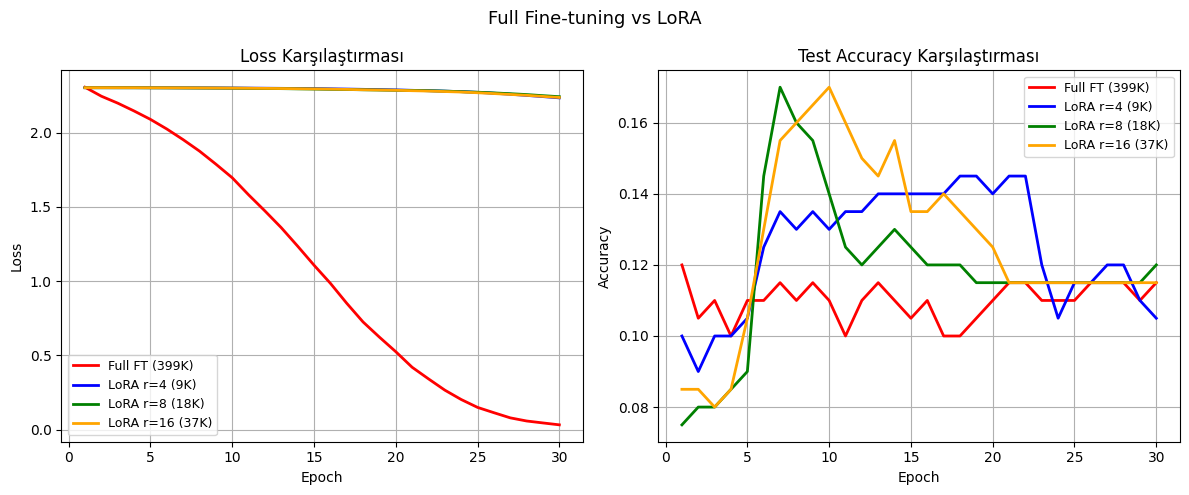


=== SONUÇLAR ===
Full FT  (399K param): 11.50%
LoRA r=4  (9K param): 10.50%
LoRA r=8 (18K param): 12.00%
LoRA r=16(37K param): 11.50%


In [6]:
# LORA EĞİTİM KARŞILAŞTIRMASI
# Normal full fine-tuning vs LoRA

# Sentetik veri
torch.manual_seed(42)
n_samples = 1000
d_model = 256
n_classes = 10

X = torch.randn(n_samples, d_model)
y = torch.randint(0, n_classes, (n_samples,))

# Train/test split
X_train, X_test = X[:800], X[800:]
y_train, y_test = y[:800], y[800:]

def train_and_compare(model, name, epochs=30, lr=0.001):
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad], lr=lr)
    criterion = nn.CrossEntropyLoss()

    losses, accs = [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X_train)
        loss = criterion(out, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_out = model(X_test)
            correct = (test_out.argmax(1) == y_test).float().mean()

        losses.append(loss.item())
        accs.append(correct.item())

    return losses, accs

# Eğit
print("Full fine-tuning eğitiliyor...")
model_full = NormalModel()
losses_full, accs_full = train_and_compare(model_full, "Full")

print("LoRA eğitiliyor (rank=4)...")
model_lora4 = ModelWithLoRA(rank=4)
losses_lora4, accs_lora4 = train_and_compare(model_lora4, "LoRA-4")

print("LoRA eğitiliyor (rank=8)...")
model_lora8 = ModelWithLoRA(rank=8)
losses_lora8, accs_lora8 = train_and_compare(model_lora8, "LoRA-8")

print("LoRA eğitiliyor (rank=16)...")
model_lora16 = ModelWithLoRA(rank=16)
losses_lora16, accs_lora16 = train_and_compare(model_lora16, "LoRA-16")

# Görselleştir
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

epochs = range(1, 31)
for losses, label, renk in [
    (losses_full, 'Full FT (399K)', 'red'),
    (losses_lora4, 'LoRA r=4 (9K)', 'blue'),
    (losses_lora8, 'LoRA r=8 (18K)', 'green'),
    (losses_lora16, 'LoRA r=16 (37K)', 'orange'),
]:
    axes[0].plot(epochs, losses, color=renk, linewidth=2, label=label)

axes[0].set_title("Loss Karşılaştırması")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=9)
axes[0].grid(True)

for accs, label, renk in [
    (accs_full, 'Full FT (399K)', 'red'),
    (accs_lora4, 'LoRA r=4 (9K)', 'blue'),
    (accs_lora8, 'LoRA r=8 (18K)', 'green'),
    (accs_lora16, 'LoRA r=16 (37K)', 'orange'),
]:
    axes[1].plot(epochs, accs, color=renk, linewidth=2, label=label)

axes[1].set_title("Test Accuracy Karşılaştırması")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=9)
axes[1].grid(True)

plt.suptitle("Full Fine-tuning vs LoRA", fontsize=13)
plt.tight_layout()
plt.show()

print("\n=== SONUÇLAR ===")
print(f"Full FT  (399K param): {accs_full[-1]:.2%}")
print(f"LoRA r=4  (9K param): {accs_lora4[-1]:.2%}")
print(f"LoRA r=8 (18K param): {accs_lora8[-1]:.2%}")
print(f"LoRA r=16(37K param): {accs_lora16[-1]:.2%}")

GERÇEK DÜNYADA LORA KULLANIMI

1. HUGGING FACE PEFT KÜTÜPHANESİ
─────────────────────────────────
pip install peft transformers

from peft import LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM

# Modeli yükle
model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-2-7b")

# LoRA konfigürasyonu
config = LoraConfig(
    r=8,                    # Rank
    lora_alpha=16,          # Scaling
    target_modules=["q_proj", "v_proj"],  # Hangi katmanlar
    lora_dropout=0.1,
    task_type="CAUSAL_LM"
)

# LoRA uygula
model = get_peft_model(model, config)
model.print_trainable_parameters()
# trainable params: 4,194,304 || all params: 6,742,609,920
# trainable%: 0.062%

2. QLORA — DAHA AZ BELLEK
─────────────────────────────────
# 4-bit quantization + LoRA = QLoRA
# 70B modeli tek GPU'da fine-tune!

from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)
model = AutoModelForCau

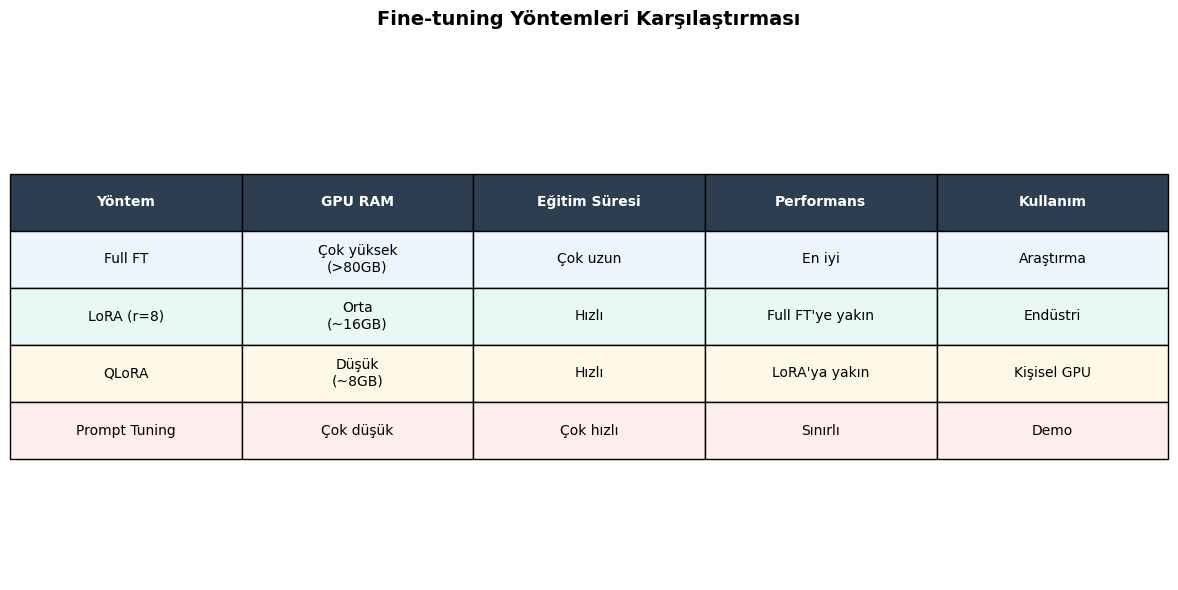

In [7]:
# GERÇEK DÜNYADA LORA — ÖZET VE REHBER

print("=" * 60)
print("GERÇEK DÜNYADA LORA KULLANIMI")
print("=" * 60)

print("""
1. HUGGING FACE PEFT KÜTÜPHANESİ
─────────────────────────────────
pip install peft transformers

from peft import LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM

# Modeli yükle
model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-2-7b")

# LoRA konfigürasyonu
config = LoraConfig(
    r=8,                    # Rank
    lora_alpha=16,          # Scaling
    target_modules=["q_proj", "v_proj"],  # Hangi katmanlar
    lora_dropout=0.1,
    task_type="CAUSAL_LM"
)

# LoRA uygula
model = get_peft_model(model, config)
model.print_trainable_parameters()
# trainable params: 4,194,304 || all params: 6,742,609,920
# trainable%: 0.062%

2. QLORA — DAHA AZ BELLEK
─────────────────────────────────
# 4-bit quantization + LoRA = QLoRA
# 70B modeli tek GPU'da fine-tune!

from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)
model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-70b",
    quantization_config=bnb_config
)

3. HANGI KATMANLARA LORA UYGULANIR?
─────────────────────────────────
Attention katmanları: q_proj, v_proj (en yaygın)
Tüm linear katmanlar: daha iyi ama daha yavaş
Sadece MLP: bazen yeterli

4. HİPERPARAMETRE REHBERİ
─────────────────────────────────
rank (r):     4-8  → hızlı, az parametre
              16   → denge
              32-64 → tam fine-tuning'e yakın
alpha:        genelde 2*r veya r
dropout:      0.05 - 0.1
lr:           1e-4 - 3e-4 (full FT'den 10x büyük olabilir)
""")

# Görsel özet
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

veri = [
    ["Yöntem", "GPU RAM", "Eğitim Süresi", "Performans", "Kullanım"],
    ["Full FT", "Çok yüksek\n(>80GB)", "Çok uzun", "En iyi", "Araştırma"],
    ["LoRA (r=8)", "Orta\n(~16GB)", "Hızlı", "Full FT'ye yakın", "Endüstri"],
    ["QLoRA", "Düşük\n(~8GB)", "Hızlı", "LoRA'ya yakın", "Kişisel GPU"],
    ["Prompt Tuning", "Çok düşük", "Çok hızlı", "Sınırlı", "Demo"],
]

tablo = ax.table(
    cellText=veri[1:],
    colLabels=veri[0],
    loc='center',
    cellLoc='center'
)
tablo.scale(1.3, 3)
tablo.auto_set_font_size(False)
tablo.set_fontsize(10)

# Başlık satırı rengi
for j in range(5):
    tablo[0, j].set_facecolor('#2C3E50')
    tablo[0, j].set_text_props(color='white', fontweight='bold')

# Satır renkleri
renkler = ['#EBF5FB', '#E8F8F5', '#FEF9E7', '#FDEDEC']
for i, renk in enumerate(renkler):
    for j in range(5):
        tablo[i+1, j].set_facecolor(renk)

ax.set_title("Fine-tuning Yöntemleri Karşılaştırması",
            fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()